In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def initialize_parameters(layers_dims, seed=None):
    """
    Args:
        layers_dims -- list of integers: dimensions of each layer in the network
        seed -- Random seed

    Returns:
        parameters -- dictionary containing W1, b1, ..., WL, bL
    """
    assert isinstance(layers_dims, list) and all(
        isinstance(x, int) and x > 0 for x in layers_dims
    )
    if seed is not None:
        np.random.seed(seed)
    else:
        np.random.seed(42)

    L = (
        len(layers_dims) - 1
    )  # Actual layers in the deep net, layer_dims[0] = no of inp features
    parameters = {}
    for l in range(1, L + 1):
        parameters[f"W{l}"] = np.random.randn(
            layers_dims[l], layers_dims[l - 1]
        ) * np.sqrt(2 / layers_dims[l - 1])
        parameters[f"b{l}"] = np.zeros((layers_dims[l], 1))
    return parameters

In [ ]:
def linear_forward(A_prev, W, b):
    """
    Args:
        A_prev -- activations from previous layer, shape (n_prev, m)
        W -- weights matrix, shape (n_curr, n_prev)
        b -- bias vector, shape (n_curr, 1)

    Returns:
        Z -- linear output, shape (n_curr, m)
        cache -- tuple containing (A_prev, W, b) for backprop
    """
    assert W.shape[1] == A_prev.shape[0], "Shape mismatch: W and A_prev"
    assert b.shape[0] == W.shape[0], "Shape mismatch: b and W"
    Z = W @ A_prev + b
    cache = (A_prev, W, b)
    return Z, cache

In [ ]:
def sigmoid(Z):
    """
    Implements the sigmoid activation.

    Args:
        Z -- linear output or a scalar value

    Returns:
        A -- sigmoid of Z
        cache -- Z (needed for backprop)
    """
    Z = np.asarray(Z, dtype=np.float64)
    A = np.where(Z >= 0, 1 / (1 + np.exp(-Z)), np.exp(Z) / (1 + np.exp(Z)))
    assert A.shape == Z.shape
    cache = Z
    return A, cache

In [ ]:
def relu(Z):
    """
    Implement the RELU function.

    Args:
        Z -- linear output or a scalar value

    Returns:
        A -- relu of Z
        cache -- Z (needed for backprop)
    """
    Z = np.asarray(Z, dtype=np.float64)
    A = np.maximum(0, Z)
    assert A.shape == Z.shape
    cache = Z
    return A, cache

In [ ]:
def activation_forward(Z, activation):
    """
    Args:
        Z -- linear output, shape (n_curr, m)
        activation -- "relu" or "sigmoid"

    Returns:
        A -- post-activation value, same shape as Z
        cache -- Z (needed for backprop)
    """
    activation = activation.lower()
    if activation == "relu":
        A, cache = relu(Z)
    elif activation == "sigmoid":
        A, cache = sigmoid(Z)
    else:
        raise ValueError("Activation must be 'relu' or 'sigmoid'")
    return A, cache

In [ ]:
def L_model_forward(X, parameters):
    """
    Args:
        X -- input data, shape (n_x, m)
        parameters -- dictionary containing W1, b1, ..., WL, bL

    Returns:
        AL -- output of the last layer (post-activation)
        caches -- list of all caches for each layer
    """
    L = len(parameters) // 2
    caches = []
    A_prev = X
    for l in range(1, L):
        Z, linear_cache = linear_forward(
            A_prev, parameters[f"W{l}"], parameters[f"b{l}"]
        )
        A, activation_cache = activation_forward(Z, "relu")
        caches.append((linear_cache, activation_cache))
        A_prev = A
    Z, linear_cache = linear_forward(A_prev, parameters[f"W{L}"], parameters[f"b{L}"])
    AL, activation_cache = activation_forward(Z, "sigmoid")
    caches.append((linear_cache, activation_cache))
    return AL, caches

In [ ]:
def linear_backward(dZ, cache):
    """
    Implement the linear portion of backward propagation for a single layer.

    Args:
        dZ -- gradient of the cost w.r.t. Z, shape (n_curr, m)
        cache -- tuple of values (A_prev, W, b) from linear_forward

    Returns:
        dA_prev -- gradient w.r.t. A_prev, shape (n_prev, m)
        dW -- gradient w.r.t. W, shape (n_curr, n_prev)
        db -- gradient w.r.t. b, shape (n_curr, 1)
    """
    A_prev, W, b = cache
    assert dZ.shape[0] == W.shape[0]
    assert A_prev.shape[0] == W.shape[1]
    assert dZ.shape[1] == A_prev.shape[1]
    m = A_prev.shape[1]
    dW = (dZ @ A_prev.T) / m
    db = np.sum(dZ, axis=1, keepdims=True) / m
    dA_prev = W.T @ dZ
    assert dA_prev.shape[0] == W.shape[1]
    assert dZ.shape[1] == dA_prev.shape[1]
    return dA_prev, dW, db

In [ ]:
def sigmoid_backward(dA, cache):
    """
    Implement the backward propagation for a single sigmoid unit

    Args:
        dA -- post-activation gradient, of any shape
        cache -- Z from activation_forward
    Returns:
        dZ -- Gradient of the cost with respect to Z
    """
    Z = cache
    S, _ = sigmoid(Z)  # extract activation A

    dZ = dA * S * (1 - S)

    assert dZ.shape == Z.shape
    return dZ

In [ ]:
def relu_backward(dA, cache):
    """
    Implement the backward propagation for a single RELU unit

    Args:
        dA -- post-activation gradient, of any shape
        cache -- Z from activation_forward

    Returns:
        dZ -- Gradient of the cost with respect to Z
    """
    Z = cache
    dZ = dA * (Z > 0)  # anything * False = 0, anything * True = anything
    assert dZ.shape == Z.shape
    return dZ

In [ ]:
def activation_backward(dA, cache, activation):
    """
    Implement the backward propagation for the activation layer.

    Args:
        dA -- gradient of the cost with respect to the post-activation output A
        cache -- tuple containing:
             (linear_cache = (A_prev, W, b),
              activation_cache = Z)
        activation -- string, "relu" or "sigmoid"

    Returns:
        dA_prev -- gradient w.r.t. A_prev
        dW -- gradient w.r.t. W
        db -- gradient w.r.t. b
    """
    linear_cache, activation_cache = cache
    if activation.lower() == "relu":
        dZ = relu_backward(dA, activation_cache)
    elif activation.lower() == "sigmoid":
        dZ = sigmoid_backward(dA, activation_cache)
    else:
        raise ValueError("Activation must be 'relu' or 'sigmoid'")
    dA_prev, dW, db = linear_backward(dZ, linear_cache)
    return dA_prev, dW, db

In [ ]:
def L_model_backward(AL, Y, caches):
    """
    Implement the backward propagation for the entire network.

    Args:
        AL -- probability vector from the forward pass, shape (1, m)
        Y -- true labels vector, shape (1, m)
        caches -- list of caches from L_model_forward, one per layer

    Returns:
        grads -- dictionary containing:
                    dA_prev for each layer (as dA{l})
                    dW for each layer (as dW{l})
                    db for each layer (as db{l})
                    Keys should be "dW1", "db1", ..., "dWL", "dbL"
    """
    L = len(caches)
    # Skipping dAL calculation and directly computing dZ because the output layer uses sigmoid activation -- more stable, elegant, efficient code.
    # dAL = - (np.divide(Y, AL) - np.divide(1 - Y, 1 - AL))
    grads = {}
    dZ = AL - Y
    idx = L - 1
    linear_cache, _ = caches[idx]
    dA_prev, dW, db = linear_backward(dZ, linear_cache)
    grads[f"dA{idx}"], grads[f"dW{idx+1}"], grads[f"db{idx+1}"] = dA_prev, dW, db
    for l in range(L - 2, -1, -1):
        dA_prev, dW, db = activation_backward(dA_prev, caches[l], "relu")
        grads[f"dA{l}"], grads[f"dW{l+1}"], grads[f"db{l+1}"] = dA_prev, dW, db
    grads.pop("dA0", None)
    return grads

In [ ]:
def compute_cost(ZL, Y):
    """
    Compute the binary cross-entropy cost using logits (numerically stable).

    Arguments:
    ZL -- pre-activation of the output layer (logits), shape (1, m)
    Y  -- true labels vector (0/1), shape (1, m)

    Returns:
    cost -- scalar representing the cost
    """
    Y = np.asarray(Y, dtype=np.float64)
    m = Y.shape[1]

    # Numerically stable BCE using logits
    term1 = np.maximum(ZL, 0)
    term2 = ZL * Y
    term3 = np.log(1 + np.exp(-np.abs(ZL)))

    cost = np.sum((term1 - term2 + term3), axis=1, keepdims=True) / m
    return cost.squeeze()  # safely converts (1,1) → scalar, keeps (k,1) as (k,)

In [ ]:
def L_layer_model(
    X,
    Y,
    layers_dims,
    learning_rate=0.0075,
    num_iterations=3000,
    print_cost=False,
    cost_tol=1e-5,
):
    """
    Implements an L-layer neural network: [LINEAR->RELU]*(L-1)->LINEAR->SIGMOID.

    Args:
        X -- input data, shape (n_x, m)
        Y -- true labels vector, shape (1, m) or (k, m) for multiple outputs
        layers_dims -- list containing the dimensions of each layer (including input and output)
        learning_rate -- learning rate for gradient descent
        num_iterations -- number of iterations for training
        print_cost -- if True, print the cost every 100 iterations
        cost_tol -- early stopping tolerance: stop if cost change < cost_tol

    Returns:
        parameters -- dictionary containing learned parameters "W1", "b1", ..., "WL", "bL"
        costs -- list of cost values every 100 iterations (for monitoring)
    """
    # Initialize parameters
    parameters = initialize_parameters(layers_dims)
    L = len(layers_dims) - 1  # actual number of layers
    costs = []

    prev_cost = float("inf")  # for early stopping

    for epoch in range(num_iterations):
        # Forward propagation
        AL, caches = L_model_forward(X, parameters)

        # Compute cost (using final layer logits for numerical stability)
        ZL = caches[-1][1]  # final layer pre-activation
        cost = compute_cost(ZL, Y)

        # Backward propagation
        grads = L_model_backward(AL, Y, caches)

        # Update parameters
        for l in range(1, L + 1):
            parameters[f"W{l}"] -= learning_rate * grads[f"dW{l}"]
            parameters[f"b{l}"] -= learning_rate * grads[f"db{l}"]

        # Print and store cost every 100 iterations
        if epoch % 100 == 0:
            if print_cost:
                print(f"Iteration {epoch}: cost = {cost:.6f}")
            costs.append(cost)

        # Early stopping
        if abs(prev_cost - cost) < cost_tol:
            if print_cost:
                print(f"Early stopping at iteration {epoch} with cost = {cost:.6f}")
            break
        prev_cost = cost

    return parameters, costs

In [ ]:
def predict_proba(X, parameters):
    """
    Compute predicted probabilities for each example using the learned parameters.

    Args:
        X -- input data, shape (n_x, m)
        parameters -- dictionary of trained weights/biases

    Returns:
        AL -- predicted probabilities, shape (1, m)
    """
    AL, _ = L_model_forward(X, parameters)
    return AL

In [ ]:
def predict(X, parameters):
    """
    Predict binary labels for each example using the learned parameters.

    Args:
        X -- input data, shape (n_x, m)
        parameters -- dictionary of trained weights/biases

    Returns:
        predictions -- array of 0/1 predictions, shape (1, m)
    """
    AL = predict_proba(X, parameters)
    predictions = (AL > 0.5).astype(int)
    return predictions

In [ ]:
def accuracy(preds, Y):
    """
    Compute accuracy between predictions and true labels.

    Args:
        preds -- predicted labels (0/1), shape (1, m)
        Y -- true labels, shape (1, m)

    Returns:
        acc -- scalar accuracy between 0 and 1
    """
    return np.mean(preds == Y)

In [ ]:
from sklearn.datasets import (
    make_circles,
    make_moons,
    make_blobs,
    make_gaussian_quantiles,
)
from sklearn.model_selection import train_test_split

In [ ]:
# ============================================================
# 2. Dataset Loader
# ============================================================
def load_extra_datasets(N=1000):
    noisy_circles = make_circles(n_samples=N, factor=0.5, noise=0.3)
    noisy_moons = make_moons(n_samples=N, noise=0.25)
    blobs = make_blobs(n_samples=N, random_state=5, n_features=2, centers=6)
    gaussian_quantiles = make_gaussian_quantiles(
        cov=0.5, n_samples=N, n_features=2, n_classes=2, shuffle=True
    )
    no_structure = (np.random.rand(N, 2), np.random.rand(N, 2))

    return noisy_circles, noisy_moons, blobs, gaussian_quantiles, no_structure

In [ ]:
# Load datasets
noisy_circles, noisy_moons, blobs, gaussian_quantiles, no_structure = (
    load_extra_datasets(1000)
)

datasets = {
    "noisy_circles": noisy_circles,
    "noisy_moons": noisy_moons,
    "blobs": blobs,
    "gaussian_quantiles": gaussian_quantiles,
}

In [ ]:
# ============================================================
# 3. Pick the dataset
# ============================================================
dataset = "noisy_moons"  # change this to try others!

X, Y = datasets[dataset]
X, Y = X.T, Y.reshape(1, -1)

# Blobs may produce >2 classes → convert to binary
if dataset == "blobs":
    Y = Y % 2

In [ ]:
# ============================================================
# 4. Visualize Dataset
# ============================================================
plt.figure(figsize=(5, 5))
plt.scatter(X[0, :], X[1, :], c=Y.flatten(), s=40, cmap=plt.cm.Spectral)
plt.title(f"Dataset: {dataset}")
plt.show()

In [ ]:
# ============================================================
# 5. Train/Test split
# ============================================================
X_train, X_test, Y_train, Y_test = train_test_split(
    X.T, Y.T, test_size=0.25, shuffle=True, stratify=Y.T, random_state=42
)
# reshape back
X_train, Y_train = X_train.T, Y_train.T
X_test, Y_test = X_test.T, Y_test.T

In [ ]:
# ============================================================
# 6. Train Deep Network
# ============================================================
layers_dims = [X_train.shape[0], 10, 10, 5, 1]

parameters, costs = L_layer_model(
    X_train,
    Y_train,
    layers_dims,
    learning_rate=0.05,
    num_iterations=5000,
    print_cost=True,
)

In [ ]:
# ============================================================
# 7. Cost Curve
# ============================================================
plt.figure(figsize=(6, 4))
plt.plot(costs)
plt.ylabel("cost")
plt.xlabel("iterations (x100)")
plt.title(f"Learning curve on {dataset}")
plt.show()

In [ ]:
# ============================================================
# 8. Evaluate on Training set and Test Set
# ============================================================
pred_train = predict(X_train, parameters)
print(f"Training Set Accuracy: {accuracy(pred_train, Y_train) * 100:.2f}%")
pred_test = predict(X_test, parameters)
print(f"Test Set Accuracy: {accuracy(pred_test, Y_test) * 100:.2f}%")

In [ ]:
# ============================================================
# 9. Decision Boundary Plotter
# ============================================================
def plot_decision_boundary(model_params, X, Y):
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    grid = np.c_[xx.ravel(), yy.ravel()].T
    Z = predict(grid, model_params)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, Z, alpha=0.55, cmap=plt.cm.Spectral)
    plt.scatter(X[0, :], X[1, :], c=Y.flatten(), s=40, cmap=plt.cm.Spectral)
    plt.title("Decision Boundary")
    plt.show()


plot_decision_boundary(parameters, X_train, Y_train)

In [ ]:
# Number of random splits
num_splits = 10

# Store accuracies
train_accuracies = []
test_accuracies = []

for split in range(num_splits):
    # Random train/test split
    X_train, X_test, Y_train, Y_test = train_test_split(
        X.T, Y.T, test_size=0.25, shuffle=True, stratify=Y.T, random_state=split
    )
    X_train, Y_train = X_train.T, Y_train.T
    X_test, Y_test = X_test.T, Y_test.T

    # Train network with same hyperparameters
    parameters, costs = L_layer_model(
        X_train,
        Y_train,
        layers_dims=[X_train.shape[0], 10, 10, 5, 1],  # your new 4-layer network
        learning_rate=0.05,
        num_iterations=3000,
        print_cost=False,
        cost_tol=1e-6,
    )

    # Compute train/test accuracy
    train_pred = predict(X_train, parameters)
    test_pred = predict(X_test, parameters)
    train_acc = accuracy(train_pred, Y_train)
    test_acc = accuracy(test_pred, Y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Average results
print(f"Average Training Accuracy: {np.mean(train_accuracies)*100:.2f}%")
print(f"Average Test Accuracy: {np.mean(test_accuracies)*100:.2f}%")
print(f"Std Training Accuracy: {np.std(train_accuracies)*100:.2f}%")
print(f"Std Test Accuracy: {np.std(test_accuracies)*100:.2f}%")

Train shape: (2, 600), (1, 600)
Validation shape: (2, 200), (1, 200)
Test shape: (2, 200), (1, 200)
Iteration 0: cost = 0.889449
Iteration 100: cost = 0.422594
Iteration 200: cost = 0.313675
Iteration 300: cost = 0.279499
Iteration 400: cost = 0.252567
Iteration 500: cost = 0.227511
Iteration 600: cost = 0.204404
Iteration 700: cost = 0.186231
Iteration 800: cost = 0.174243
Iteration 900: cost = 0.165955
Iteration 1000: cost = 0.159993
Iteration 1100: cost = 0.155551
Iteration 1200: cost = 0.152380
Iteration 1300: cost = 0.149990
Iteration 1400: cost = 0.147977
Iteration 1500: cost = 0.146302
Iteration 1600: cost = 0.144880
Early stopping at iteration 1647 with cost = 0.144283
Validation Set Accuracy: 95.00%


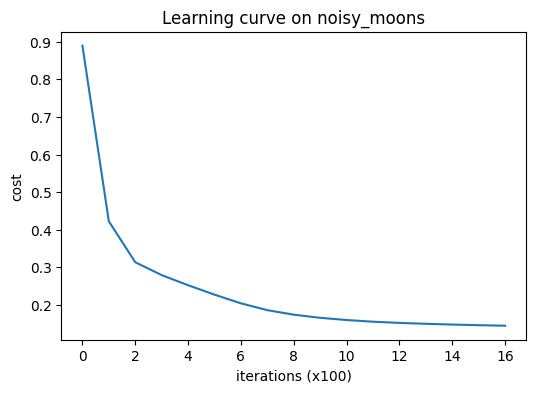

Training Set Accuracy: 94.00%
Validation Set Accuracy: 95.00%
Test Set Accuracy: 91.50%


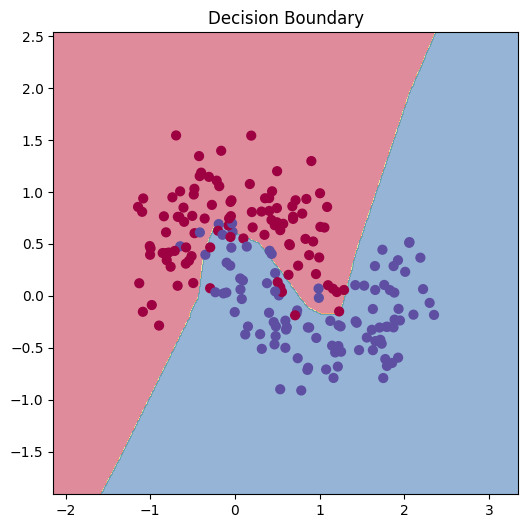

In [ ]:
# ============================================================
# 5. Train/Validation/Test split
# ============================================================
# First split: train + temp (validation + test)
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X.T, Y.T, test_size=0.4, shuffle=True, stratify=Y.T, random_state=42
)

# Second split: validation + test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, shuffle=True, stratify=Y_temp, random_state=42
)

# Reshape back for neural network (features, examples)
X_train, Y_train = X_train.T, Y_train.T
X_val, Y_val = X_val.T, Y_val.T
X_test, Y_test = X_test.T, Y_test.T

print(f"Train shape: {X_train.shape}, {Y_train.shape}")
print(f"Validation shape: {X_val.shape}, {Y_val.shape}")
print(f"Test shape: {X_test.shape}, {Y_test.shape}")

# ============================================================
# 6. Train Deep Network (with validation monitoring)
# ============================================================
layers_dims = [X_train.shape[0], 10, 10, 5, 1]
parameters, costs = L_layer_model(
    X_train,
    Y_train,
    layers_dims,
    learning_rate=0.05,
    num_iterations=5000,
    print_cost=True,
)

# Optionally, compute validation accuracy
val_pred = predict(X_val, parameters)
print(f"Validation Set Accuracy: {accuracy(val_pred, Y_val) * 100:.2f}%")

# ============================================================
# 7. Cost Curve (training cost)
# ============================================================
plt.figure(figsize=(6, 4))
plt.plot(costs)
plt.ylabel("cost")
plt.xlabel("iterations (x100)")
plt.title(f"Learning curve on {dataset}")
plt.show()

# ============================================================
# 8. Evaluate on Training, Validation, and Test Sets
# ============================================================
train_pred = predict(X_train, parameters)
print(f"Training Set Accuracy: {accuracy(train_pred, Y_train) * 100:.2f}%")

val_pred = predict(X_val, parameters)
print(f"Validation Set Accuracy: {accuracy(val_pred, Y_val) * 100:.2f}%")

test_pred = predict(X_test, parameters)
print(f"Test Set Accuracy: {accuracy(test_pred, Y_test) * 100:.2f}%")

# ============================================================
# 9. Decision Boundary on Test Set
# ============================================================
plot_decision_boundary(parameters, X_test, Y_test)